Loading k-space data from /2022062501_T203.h5
K-space data shape: (18, 4, 256, 256)
Generating radial undersampling mask at rate 0.5
Applying undersampling
Computing graph Laplacian
Laplacian shape: (65536, 65536)
Computing spectral graph wavelets
Wavelet coefficients shape: (30, 256, 256)
Performing projected fast iterative soft thresholding reconstruction
Removing Gibbs artifacts
Computing reconstruction metrics
{'PSNR': 30.067986782105077, 'SSIM': 0.7853720537147522, 'RMSE': 0.03099379688501358, 'RLNE': 0.16122335195541382}
Plotting results


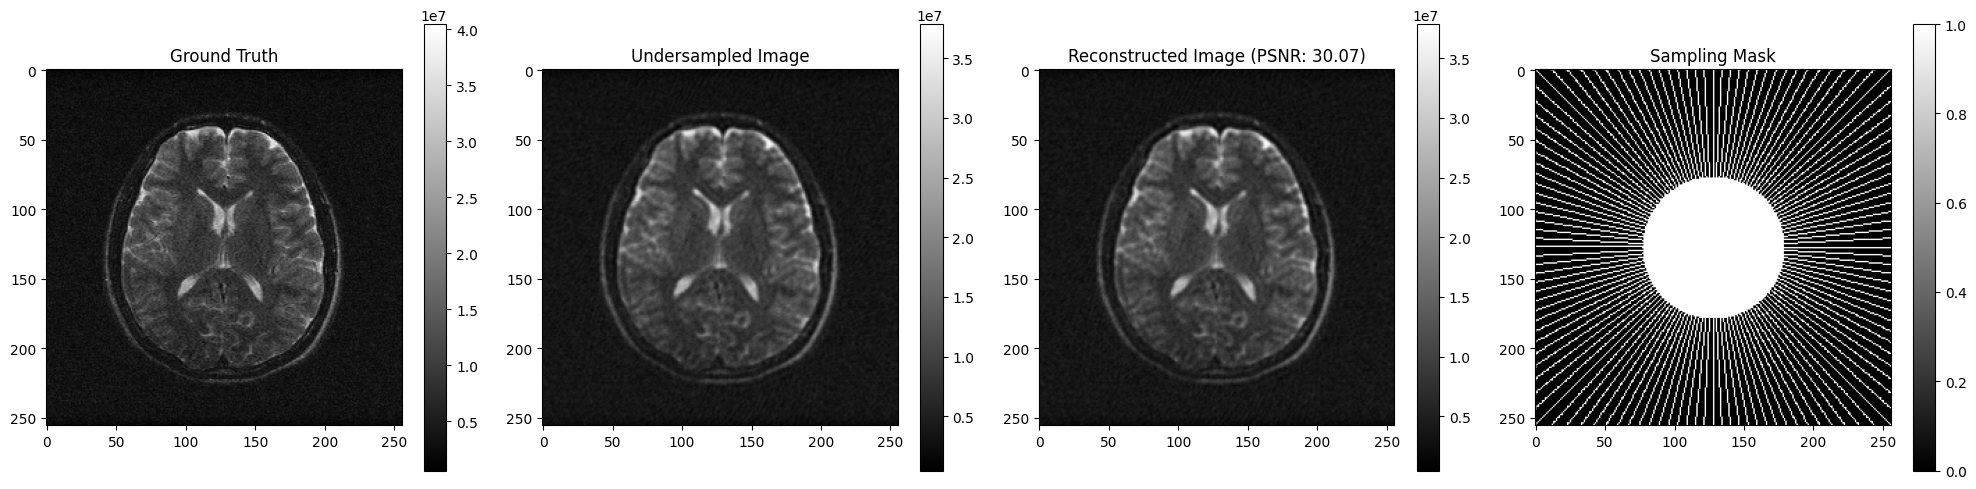

In [ ]:
import h5py
import numpy as np
import scipy.fftpack as fft
import scipy.sparse.linalg as linalg
import scipy.sparse as sp
from scipy.sparse import diags
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter


# ======================
# Module 1: Preprocessing and Mask Generation
# ======================
def load_kspace_data(h5_file):
    with h5py.File(h5_file, 'r') as f:
        kspace_data = f['kspace'][:]
    return kspace_data

def normalize_kspace(kspace, percentile=1, epsilon=1e-8):
    abs_kspace = np.abs(kspace)
    max_val = np.percentile(abs_kspace, percentile)
    return kspace / (max_val + epsilon)

def fft2c(image):
    return fft.ifftshift(fft.fft2(fft.fftshift(image)))

def ifft2c(kspace):
    return fft.ifftshift(fft.ifft2(fft.fftshift(kspace)))

def undersample_kspace(kspace, mask):
    return kspace * mask

def generate_undersampling_mask(shape, rate, mask_type='cartesian'):
    if mask_type == 'cartesian':
        return generate_cartesian_mask(shape, rate)
    elif mask_type == 'radial':
        return generate_radial_mask(shape, rate)
    elif mask_type == 'random':
        return generate_random_mask(shape, rate)
    elif mask_type == 'variable_density':
        return generate_variable_density_mask(shape, rate)
    else:
        raise ValueError(f"Unknown mask type: {mask_type}")

def generate_cartesian_mask(shape, rate, center_fraction=0.4):
    mask = np.zeros(shape, dtype=bool)
    num_cols = shape[1]
    center_width = int(num_cols * center_fraction)
    center_start = (num_cols - center_width) // 2
    mask[:, center_start:center_start+center_width] = True
    num_samples = int(rate * num_cols) - center_width
    outer_cols = list(range(0, center_start)) + list(range(center_start+center_width, num_cols))
    sampled_cols = np.random.choice(outer_cols, size=num_samples, replace=False)
    mask[:, sampled_cols] = True
    return mask

def generate_radial_mask(shape, rate, center_fraction=0.4):
    mask = np.zeros(shape, dtype=bool)
    num_lines = int(shape[1] * rate)
    center_y, center_x = shape[0] // 2, shape[1] // 2
    center_radius = int(min(shape) * center_fraction // 2)
    y, x = np.ogrid[-center_y:shape[0]-center_y, -center_x:shape[1]-center_x]
    center_mask = x*x + y*y <= center_radius*center_radius
    mask[center_mask] = True
    angles = np.linspace(0, 2 * np.pi, num_lines, endpoint=False)
    for angle in angles:
        x = np.cos(angle)
        y = np.sin(angle)
        points = np.array([[x * i, y * i] for i in range(max(shape))])
        points = points + np.array([center_y, center_x])
        points = points.astype(int)
        valid_points = (points[:, 0] >= 0) & (points[:, 0] < shape[0]) & \
                       (points[:, 1] >= 0) & (points[:, 1] < shape[1])
        mask[points[valid_points, 0], points[valid_points, 1]] = True

    return mask

def generate_random_mask(shape, rate, center_fraction=0.5):
    mask = np.zeros(shape, dtype=bool)
    center = [s//2 for s in shape]
    c_radius = int(center_fraction * min(shape)//2)
    cy, cx = np.ogrid[-center[0]:shape[0]-center[0],
                      -center[1]:shape[1]-center[1]]
    central_mask = (cy**2 + cx**2) <= c_radius**2
    mask[central_mask] = True
    peripheral_mask = ~central_mask
    num_peripheral = int(rate * np.prod(shape) - np.sum(central_mask))
    prob = num_peripheral / np.sum(peripheral_mask)
    peripheral_samples = np.random.rand(*shape) < prob
    mask = mask | (peripheral_mask & peripheral_samples)

    return mask

def generate_variable_density_mask(shape, rate, power=4):
    mask = np.zeros(shape, dtype=bool)
    center = np.array(shape) // 2
    y, x = np.ogrid[:shape[0], :shape[1]]
    distances = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    distances = distances / np.max(distances)
    prob = (1 - distances)**power
    prob /= prob.sum()
    num_samples = int(rate * np.prod(shape))
    flat_indices = np.random.choice(np.prod(shape), size=num_samples, replace=False, p=prob.flatten())
    mask.flat[flat_indices] = True
    return mask



# ======================
# Module 2: Graph Construction
# ======================

def compute_graph_laplacian(image, num_neighbors=16):
    magnitude_image = np.abs(image)
    shape = magnitude_image.shape
    num_nodes = np.prod(shape)
    pixels = magnitude_image.reshape(-1, 1)

    # Use NearestNeighbors for efficient k-nearest neighbor search
    nn = NearestNeighbors(n_neighbors=num_neighbors, metric='euclidean', n_jobs=-1)
    nn.fit(pixels)

    # Compute distances and indices of nearest neighbors
    distances, indices = nn.kneighbors(pixels)

    # Compute weights using Gaussian kernel
    sigma = np.mean(distances)
    weights = np.exp(-distances**2 / (2 * sigma**2))

    # Construct sparse adjacency matrix
    row_indices = np.repeat(np.arange(num_nodes), num_neighbors)
    col_indices = indices.ravel()
    adj_matrix = sp.csr_matrix((weights.ravel(), (row_indices, col_indices)), shape=(num_nodes, num_nodes))

    # Make the adjacency matrix symmetric
    adj_matrix = (adj_matrix + adj_matrix.T) / 2

    # Compute degree matrix
    degree_matrix = sp.diags(adj_matrix.sum(axis=1).A1, 0)

    # Compute Laplacian matrix
    laplacian = degree_matrix - adj_matrix

    return laplacian


# ======================
# Module 3: SGWT Reconstruction
# ======================

def scaling_function(lambdas):
    """
    Low-pass filter for scaling functions.
    Args:
        lambdas: Eigenvalues of the graph Laplacian.

    Returns:
        Filtered eigenvalues.
    """
    return np.exp(-lambdas)

def sgwt_kernel(lambdas):
    """
    SGWT kernel function acting as a band-pass filter.
    Args:
        lambdas: Eigenvalues of the graph Laplacian (array or scalar).

    Returns:
        Filtered eigenvalues (array or scalar).
    """
    return lambdas * np.exp(-lambdas / 2)



def chebyshev_polynomial(L, order=10):
    """
    Compute Chebyshev polynomial approximation for SGWT.
    Args:
        L: Graph Laplacian matrix.
        order: Order of Chebyshev polynomial approximation.

    Returns:
        T_k: List of Chebyshev polynomials.
        lambda_max: Maximum eigenvalue of L.
    """
    N = L.shape[0]

    # Estimate maximum eigenvalue of L
    lambda_max = sp.linalg.eigsh(L, k=1, which='LM', return_eigenvectors=False)[0]

    # Scale Laplacian for numerical stability
    L_scaled = (2 / lambda_max) * L - sp.identity(N)

    # Compute Chebyshev polynomials
    T_k = [sp.identity(N), L_scaled]
    for k in range(2, order):
        T_k.append(2 * L_scaled @ T_k[-1] - T_k[-2])

    return T_k, lambda_max


def sgwt(image, L, order=10):
    """
    Spectral Graph Wavelet Transform (SGWT).
    Args:
        image: Input image (2D array).
        L: Graph Laplacian matrix.
        order: Order of Chebyshev polynomial approximation.

    Returns:
        Wavelet coefficients.
    """
    # Flatten image for graph processing
    image_vec = image.flatten()

    # Compute Chebyshev polynomial approximation
    T_k, lambda_max = chebyshev_polynomial(L, order)

    # Apply SGWT kernel (band-pass filter)
    wavelet_coeffs = []
    kernel = sgwt_kernel(np.linspace(0, lambda_max, order))  # Generate kernel for all orders
    for t in range(order):
        filtered_coeffs = sum(kernel[i] * T_k[i] @ image_vec for i in range(len(T_k)))
        wavelet_coeffs.append(filtered_coeffs)

    # Reshape wavelet coefficients back to image shape
    return np.array(wavelet_coeffs).reshape(order, *image.shape)



def inverse_sgwt(wavelet_coeffs, L, order=10):
    """
    Inverse Spectral Graph Wavelet Transform (SGWT).
    Args:
        wavelet_coeffs: Wavelet coefficients from SGWT.
        L: Graph Laplacian matrix.
        order: Order of Chebyshev polynomial approximation.

    Returns:
        Reconstructed image.
    """
    T_k, lambda_max = chebyshev_polynomial(L, order)

    # Reconstruct image by summing contributions from all scales
    reconstructed_image = np.zeros_like(wavelet_coeffs[0])
    for t in range(order):
        kernel = sgwt_kernel(t * lambda_max / order)
        reconstructed_image += sum(kernel[i] * T_k[i] @ wavelet_coeffs[t].flatten() for i in range(len(T_k)))

    return reconstructed_image.reshape(wavelet_coeffs.shape[1:])


def pfista(y, mask, lambda_reg=0.001, gamma=0.1, max_iter=200, tol=1e-6):
    """
    Projected Fast Iterative Soft-Thresholding Algorithm (pFISTA).
    Args:
        y: Undersampled k-space data.
        mask: Sampling mask (True = sampled, False = undersampled).
        lambda_reg: Regularization parameter for soft-thresholding.
        gamma: Step size (0 < gamma <= 1).
        max_iter: Maximum number of iterations.
        tol: Convergence tolerance.

    Returns:
        Reconstructed image.
    """
    # Initialize variables
    x_prev = ifft2c(y).copy()
    y_k = x_prev.copy()
    t_prev = 1

    # Ensure mask is boolean
    mask = mask.astype(bool)

    for k in range(max_iter):
        # Gradient descent step
        grad_f_yk = ifft2c(mask * (fft2c(y_k) - y))  # Only compute gradient for sampled regions
        x_new_temp = y_k - gamma * grad_f_yk

        # Soft-thresholding (apply sparsity constraint)
        x_thresholded = np.sign(x_new_temp) * np.maximum(np.abs(x_new_temp) - lambda_reg * gamma, 0)

        # Update only undersampled regions
        x_new_image = x_prev.copy()
        x_new_image[~mask] = x_thresholded[~mask]  # Update only where mask is False

        # Momentum update
        t_new = (1 + np.sqrt(1 + 4 * t_prev**2)) / 2
        y_k = x_new_image + ((t_prev - 1) / t_new) * (x_new_image - x_prev)

        # Convergence check
        """rel_diff = np.linalg.norm(x_new_image - x_prev) / (np.linalg.norm(x_prev) + 1e-8)
        if rel_diff < tol:
            print(f"Converged at iteration {k+1}")
            break"""

        # Update variables for next iteration
        x_prev = x_new_image.copy()
        t_prev = t_new

    return x_new_image



# ======================
# Module 4: Post-processing
# ======================
def remove_gibbs_artifacts(image, sigma=0.2):
    return gaussian_filter(np.abs(image), sigma=sigma)

# ======================
# Module 5: Evaluation & Visualization
# ======================

def calculate_metrics(gt, recon):
    gt = np.abs(gt)/np.max(np.abs(gt))
    recon = np.abs(recon)/np.max(np.abs(recon))
    data_range = np.max([gt, recon]) - np.min([gt, recon])
    return {
        'PSNR': float(psnr(gt, recon, data_range=data_range)),
        'SSIM': float(ssim(gt, recon, data_range=data_range)),
        'RMSE': float(np.sqrt(np.mean((gt - recon)**2))),
        'RLNE': float(np.linalg.norm(gt - recon)/np.linalg.norm(gt))
    }

def plot_results(gt, undersampled, recon, mask, metrics):
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(np.abs(gt), cmap='gray')
    plt.title(f'Ground Truth')
    plt.colorbar()

    plt.subplot(1, 4, 2)
    plt.imshow(np.abs(undersampled), cmap='gray')
    plt.title('Undersampled Image')
    plt.colorbar()

    plt.subplot(1, 4, 3)
    plt.imshow(np.abs(recon), cmap='gray')
    plt.title(f'Reconstructed Image (PSNR: {metrics["PSNR"]:.2f})')
    plt.colorbar()

    plt.subplot(1, 4, 4)
    plt.imshow(mask, cmap='gray')
    plt.title('Sampling Mask')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

# ======================
# Main Pipeline
# ======================

def main(h5_file, rate, mask_type, slice_idx=0, lambda_reg=0.005, lambda_tv=0.002,
         iterations=200, tol=1e-6, use_tv=True):
    print(f"Loading k-space data from {h5_file}")
    kspace_data = load_kspace_data(h5_file)
    print(f"K-space data shape: {kspace_data.shape}")

    kspace_data= normalize_kspace(kspace_data)

    # Assuming multi-coil data, combine coils using RSS
    kspace_slice = kspace_data[slice_idx]
    image_coils = ifft2c(kspace_slice)
    ground_truth_image = np.sqrt(np.sum(np.abs(image_coils)**2, axis=0))

    print(f"Generating {mask_type} undersampling mask at rate {rate}")
    mask = generate_undersampling_mask(ground_truth_image.shape, rate, mask_type)

    print("Applying undersampling")
    slice_kspace = fft2c(ground_truth_image)
    slice_undersampled = undersample_kspace(slice_kspace, mask)
    undersampled_image = ifft2c(slice_undersampled)

    print(f"Computing graph Laplacian")
    L = compute_graph_laplacian(undersampled_image, num_neighbors=8)
    print(f"Laplacian shape: {L.shape}")

    print("Computing spectral graph wavelets")
    wavelet_coeffs = sgwt(undersampled_image, L, order=30)
    print(f"Wavelet coefficients shape: {wavelet_coeffs.shape}")

    print("Performing projected fast iterative soft thresholding reconstruction")
    reconstructed_image = pfista(slice_undersampled,mask,max_iter=iterations)
    print("Removing Gibbs artifacts")
    reconstructed_image= remove_gibbs_artifacts(reconstructed_image)
    print("Computing reconstruction metrics")
    metrics = calculate_metrics(ground_truth_image, reconstructed_image)
    print(metrics)
    print("Plotting results")
    plot_results(ground_truth_image, undersampled_image, reconstructed_image, mask, metrics)

    return {
        'ground_truth': ground_truth_image,
        'undersampled': undersampled_image,
        'reconstructed': reconstructed_image,
        'metrics': metrics,
        'wavelet_coeffs': wavelet_coeffs,
        'mask': mask
    }

if __name__ == "__main__":
    main('/2022062501_T203.h5', rate=0.5, mask_type='radial', slice_idx=7, iterations=5, tol=1e-6)
